In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [10]:
urban = pd.read_csv('urbandata.csv')
urban.head()

,inspector_id,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,inspection_season,inspection_window,moisture_stress,failure
0,5,31.762605,12.891996,4.711064,71.480592,9.429642,5.177088,2.9944,summer,afternoon,0.06,1
1,7,30.770158,11.835563,3.315888,60.300892,8.655641,4.927622,2.6808,spring,morning,0.01,0
2,6,31.591296,11.738267,2.425562,56.367965,9.017137,4.910945,2.5294,autumn,night,0.02,0
3,5,30.834649,11.622881,2.164486,53.135138,8.864650,4.949554,2.4810,autumn,afternoon,0.02,1
4,2,33.315981,12.616065,4.557082,77.482269,9.549344,5.047689,3.0460,summer,morning,0.07,1


In [11]:
len(urban)

456

In [12]:
urban.isna().sum()

,0
inspector_id,0
material_flexibility,0
structural_mass_ratio,1
recent_precipitation,2
infrastructure_age,4
surface_debris,0
vibration_exposure,1
asset_density,0
inspection_season,0
inspection_window,0


In [13]:
urban

,inspector_id,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,inspection_season,inspection_window,moisture_stress,failure
0,5,31.762605,12.891996,4.711064,71.480592,9.429642,5.177088,2.99440,summer,afternoon,0.06,1
1,7,30.770158,11.835563,3.315888,60.300892,8.655641,4.927622,2.68080,spring,morning,0.01,0
2,6,31.591296,11.738267,2.425562,56.367965,9.017137,4.910945,2.52940,autumn,night,0.02,0
3,5,30.834649,11.622881,2.164486,53.135138,8.864650,4.949554,2.48100,autumn,afternoon,0.02,1
4,2,33.315981,12.616065,4.557082,77.482269,9.549344,5.047689,3.04600,summer,morning,0.07,1
...,...,...,...,...,...,...,...,...,...,...,...,...
451,5,30.154152,11.816298,2.120903,57.140895,8.778138,5.030630,2.53112,spring,afternoon,0.00,0
452,10,32.254170,11.779914,2.841949,61.490869,9.300330,4.930623,2.56308,autumn,night,0.02,0
453,6,28.465334,11.506094,0.000000,62.438486,8.169076,4.743956,2.20000,winter,afternoon,0.04,0
454,9,31.813525,12.015377,3.655757,54.803893,9.256184,4.990145,2.84280,summer,night,0.06,1


In [14]:
urban[urban.isnull().any(axis=1)]

,inspector_id,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,inspection_season,inspection_window,moisture_stress,failure
30,1,31.906319,11.812803,2.694545,55.774162,9.181269,4.886832,2.56692,autumn,morning,NaN,0
31,4,28.405858,11.681774,1.836554,63.334801,8.302755,4.955494,2.46240,autumn,night,NaN,0
32,9,32.064930,11.857232,3.660226,52.551259,9.048581,4.952309,2.73400,winter,afternoon,NaN,0
131,2,30.733149,11.575091,2.042268,66.392515,8.579636,NaN,2.39064,winter,night,0.01,0
188,2,36.636688,12.939398,5.207587,NaN,10.109317,5.057439,3.06920,summer,afternoon,0.02,1
212,10,29.858813,11.718220,NaN,50.800519,8.546346,4.876125,2.47016,winter,afternoon,0.01,0
376,2,34.777433,13.013540,5.406268,NaN,10.185214,4.988152,3.22000,summer,morning,0.06,1
380,3,36.419436,12.313568,4.531669,NaN,10.656180,4.961130,2.92800,autumn,night,0.03,1
413,3,30.036887,11.535464,1.123544,NaN,8.568975,4.993997,2.28088,summer,night,0.03,0
427,7,36.262647,12.226942,NaN,94.172578,11.078386,4.944079,2.85000,summer,afternoon,0.06,1


In [15]:
len(urban[urban.isnull().any(axis=1)])

11

With 456 rows, removing 11 rows would not cause any issues and I cannot estimate values over there



In [17]:
urban = urban.fillna(urban.median(numeric_only=True))

In [18]:
len(urban)

456

In [19]:
urban.inspector_id.unique()

array([ 5,  7,  6,  2,  8,  9, 10,  1,  4,  3, 11])

So far there are 11 inspector id's

(array([195., 247.,  12.,   0.,   0.,   0.,   0.,   0.,   0.,   2.]),
 array([24.9247646 , 31.54807944, 38.17139428, 44.79470913, 51.41802397,
        58.04133881, 64.66465365, 71.28796849, 77.91128333, 84.53459817,
        91.15791301]),
 <BarContainer object of 10 artists>)

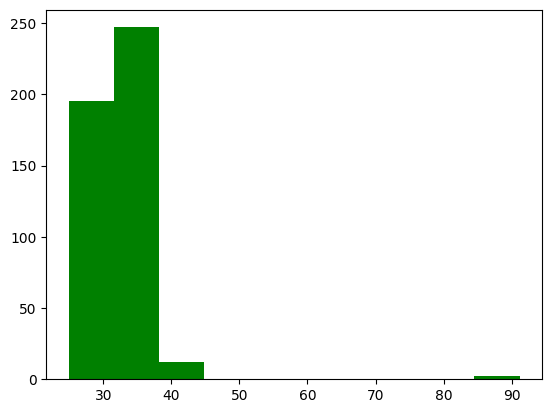

In [22]:
plt.hist(urban.material_flexibility,color="green")

In [23]:
min(urban.material_flexibility[urban.material_flexibility<50])

24.9247646027265

In [24]:
max(urban.material_flexibility[urban.material_flexibility<50])

40.4529810930904

(array([  3.,  13.,  42., 106., 112.,  76.,  39.,  45.,  12.,   6.]),
 array([24.9247646 , 26.47758625, 28.0304079 , 29.58322955, 31.1360512 ,
        32.68887285, 34.2416945 , 35.79451615, 37.3473378 , 38.90015944,
        40.45298109]),
 <BarContainer object of 10 artists>)

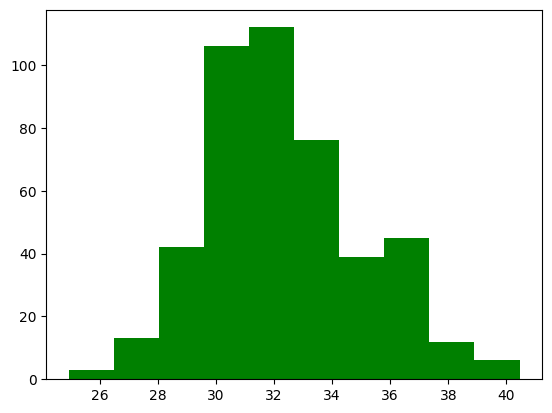

In [25]:
plt.hist(urban.material_flexibility[urban.material_flexibility<50],color="green")

In [57]:
urban['inspection_window'] = urban['inspection_window'].replace({'morni7ng': 'morning'})
urban['inspection_season'] = urban['inspection_season'].replace({'sumer': 'summer'})

In [58]:
urban_copy = urban.copy()
urban_copy = urban_copy[urban_copy.material_flexibility<50]

In [59]:
y = urban_copy.failure
x = urban_copy.drop(columns=['failure',"inspector_id"])

In [60]:
x.head()

,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,inspection_season,inspection_window,moisture_stress
0,31.762605,12.891996,4.711064,71.480592,9.429642,5.177088,2.9944,summer,afternoon,0.06
1,30.770158,11.835563,3.315888,60.300892,8.655641,4.927622,2.6808,spring,morning,0.01
2,31.591296,11.738267,2.425562,56.367965,9.017137,4.910945,2.5294,autumn,night,0.02
3,30.834649,11.622881,2.164486,53.135138,8.864650,4.949554,2.4810,autumn,afternoon,0.02
4,33.315981,12.616065,4.557082,77.482269,9.549344,5.047689,3.0460,summer,morning,0.07


In [61]:
y.head()

,failure
0,1
1,0
2,0
3,1
4,1


In [62]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [63]:
x_train_transform = x_train.copy()
x_test_transform = x_test.copy()

In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import recall_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits models using 5-fold stratified cross-validation on training data,
    prints each fold score, then evaluates once on test set.
    """
    np.random.seed(42)
    model_scores = {}

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for name, model in models.items():
        print(f"\n===== {name} =====")

        # 1️⃣ Cross-validation on training set
        cv_scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring="recall"
        )

        # Print each fold score
        for i, score in enumerate(cv_scores, 1):
            print(f"Fold {i} Recall: {score:.4f}")

        print(f"Mean CV Recall: {cv_scores.mean():.4f}")

        # 2️⃣ Fit on full training data
        model.fit(X_train, y_train)

        # 3️⃣ Evaluate on test set
        y_pred = model.predict(X_test)
        test_score = recall_score(y_test, y_pred)

        print(f"Test Recall: {test_score:.4f}")

        model_scores[name] = {
            "CV Scores": cv_scores,
            "Mean CV Recall": cv_scores.mean(),
            "Test Recall": test_score
        }

    return model_scores

In [65]:
numeric_features = ['material_flexibility', 'structural_mass_ratio', 'recent_precipitation', 'infrastructure_age', 'surface_debris', 'vibration_exposure', 'asset_density', 'moisture_stress']
categorical_features = ['inspection_season', 'inspection_window']

In [66]:
categorical_features_no_inspector = [col for col in categorical_features if col != 'inspector_id']

ct_no_inspector = ColumnTransformer(
    transformers=[
        ("rs", RobustScaler(), numeric_features),
        ("ohe", OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop="first"), categorical_features_no_inspector),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

models_no_inspector = {
    "Logistic Regression": Pipeline([
        ('preprocessor', ct_no_inspector),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ('preprocessor', ct_no_inspector),
        ('model', RandomForestClassifier(random_state=42))
    ]),
    "MLP Classifier": Pipeline([
        ('preprocessor', ct_no_inspector),
        ('model', MLPClassifier(random_state=42, max_iter=1000))
    ])
}

model_scores_no_inspector = fit_and_score(models_no_inspector, x_train_transform, x_test_transform, y_train, y_test)
print("Model scores with inspector_id removed:", model_scores_no_inspector)


===== Logistic Regression =====
Fold 1 Recall: 0.7857
Fold 2 Recall: 0.8929
Fold 3 Recall: 0.8214
Fold 4 Recall: 0.9643
Fold 5 Recall: 0.8214
Mean CV Recall: 0.8571
Test Recall: 0.8929

===== Random Forest =====
Fold 1 Recall: 0.8214
Fold 2 Recall: 0.8929
Fold 3 Recall: 0.8214
Fold 4 Recall: 0.8929
Fold 5 Recall: 0.8214
Mean CV Recall: 0.8500
Test Recall: 0.8571

===== MLP Classifier =====
Fold 1 Recall: 0.8214
Fold 2 Recall: 0.9286
Fold 3 Recall: 0.8214
Fold 4 Recall: 0.8571
Fold 5 Recall: 0.7857
Mean CV Recall: 0.8429
Test Recall: 0.8929
Model scores with inspector_id removed: {'Logistic Regression': {'CV Scores': array([0.78571429, 0.89285714, 0.82142857, 0.96428571, 0.82142857]), 'Mean CV Recall': np.float64(0.8571428571428571), 'Test Recall': 0.8928571428571429}, 'Random Forest': {'CV Scores': array([0.82142857, 0.89285714, 0.82142857, 0.89285714, 0.82142857]), 'Mean CV Recall': np.float64(0.85), 'Test Recall': 0.8571428571428571}, 'MLP Classifier': {'CV Scores': array([0.8214285

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [67]:
from sklearn.metrics import classification_report, confusion_matrix

In [68]:
for model_name, model_pipeline in models_no_inspector.items():
    print(f"\n--- Evaluating {model_name} with Inspector ID Removed ---")
    y_pred = model_pipeline.predict(x_test_transform)

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


--- Evaluating Logistic Regression with Inspector ID Removed ---
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        63
           1       0.89      0.89      0.89        28

    accuracy                           0.93        91
   macro avg       0.92      0.92      0.92        91
weighted avg       0.93      0.93      0.93        91

Confusion Matrix:
[[60  3]
 [ 3 25]]

--- Evaluating Random Forest with Inspector ID Removed ---
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.94        63
           1       0.89      0.86      0.87        28

    accuracy                           0.92        91
   macro avg       0.91      0.90      0.91        91
weighted avg       0.92      0.92      0.92        91

Confusion Matrix:
[[60  3]
 [ 4 24]]

--- Evaluating MLP Classifier with Inspector ID Removed ---
Classification Report:
              pr

In [69]:
ct_fitted_logreg = models_no_inspector["Logistic Regression"].named_steps["preprocessor"]
print("ColumnTransformer extracted successfully.")

ColumnTransformer extracted successfully.


In [70]:
transformed_feature_names = ct_fitted_logreg.get_feature_names_out()
print(f"Number of transformed features: {len(transformed_feature_names)}")
print("Transformed feature names extracted successfully.")

Number of transformed features: 13
Transformed feature names extracted successfully.


In [71]:
logreg_model = models_no_inspector["Logistic Regression"].named_steps["model"]
logreg_coefficients = logreg_model.coef_[0]
print(f"Extracted {len(logreg_coefficients)} coefficients from Logistic Regression model.")

Extracted 13 coefficients from Logistic Regression model.


In [72]:
logreg_feature_importance_df = pd.DataFrame({
    'Feature': transformed_feature_names,
    'Coefficient': logreg_coefficients
})
logreg_feature_importance_df['Abs_Coefficient'] = abs(logreg_feature_importance_df['Coefficient'])
logreg_feature_importance_df = logreg_feature_importance_df.sort_values(by='Abs_Coefficient', ascending=False)
print("Logistic Regression feature importance DataFrame created and sorted.")
print(logreg_feature_importance_df.head())

Logistic Regression feature importance DataFrame created and sorted.
                     Feature  Coefficient  Abs_Coefficient
9   inspection_season_summer     2.116785         2.116785
10  inspection_season_winter    -1.827566         1.827566
4             surface_debris     1.250932         1.250932
8   inspection_season_spring    -1.142975         1.142975
0       material_flexibility     1.036189         1.036189


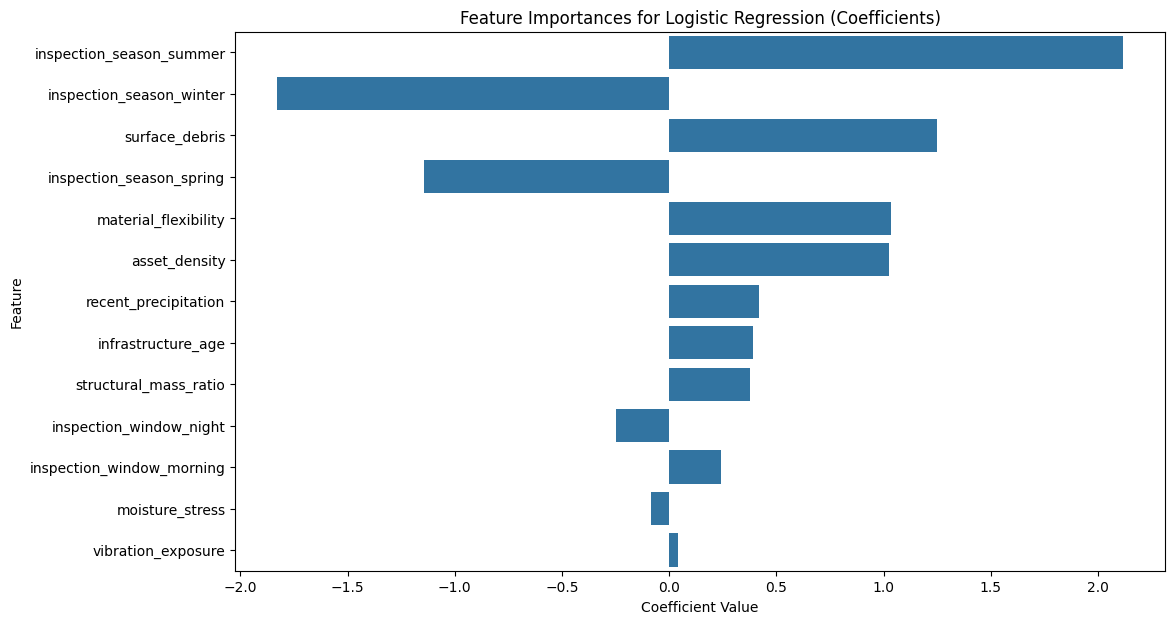

In [74]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Coefficient', y='Feature', data=logreg_feature_importance_df)
plt.title('Feature Importances for Logistic Regression (Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()


In [75]:
rf_model = models_no_inspector["Random Forest"].named_steps["model"]
rf_importances = rf_model.feature_importances_
print(f"Extracted {len(rf_importances)} feature importances from Random Forest model.")

Extracted 13 feature importances from Random Forest model.


In [76]:
rf_feature_importance_df = pd.DataFrame({
    'Feature': transformed_feature_names,
    'Importance': rf_importances
})
rf_feature_importance_df = rf_feature_importance_df.sort_values(by='Importance', ascending=False)
print("Random Forest feature importance DataFrame created and sorted.")
print(rf_feature_importance_df.head())

Random Forest feature importance DataFrame created and sorted.
                 Feature  Importance
4         surface_debris    0.231072
6          asset_density    0.194497
0   material_flexibility    0.152285
2   recent_precipitation    0.098732
1  structural_mass_ratio    0.079569
